In [1]:
include("BarrierSynthesis.jl")

compute_next_level_barriersPM (generic function with 1 method)

# 0. Init system variable and parameters

In [2]:
#init state and input variables
@polyvar u[1:2]
@polyvar(x[1:7]) # x[1] is x, x[2] is y, x[3] is vel_x, x[4] is vel_y, x[5] is θ, x[6] is ω, x[7] is error

#define system dynamics
dynamics = [
        (ctrl -> [x[3],x[4], (ctrl[1]+ctrl[2])*(-2.0/π)*(x[5]+π)-0.2x[7], (ctrl[1]+ctrl[2])*((2.0/π)*(x[5] + π/2.0)-0.2x[7])-2, x[6], ctrl[1]-ctrl[2], 0.]),
        (ctrl -> [x[3],x[4], (ctrl[1]+ctrl[2])*(2.0/π)*x[5]+0.2x[7], (ctrl[1]+ctrl[2])*((2.0/π)*(x[5] + π/2.0)-0.2x[7])-2, x[6], ctrl[1]-ctrl[2], 0.]),
        (ctrl -> [x[3],x[4], (ctrl[1]+ctrl[2])*(2.0/π)*x[5]+0.2x[7], (ctrl[1]+ctrl[2])*((-2.0/π)*(x[5] - π/2.0)+0.2x[7])-2, x[6], ctrl[1]-ctrl[2], 0.]),
        (ctrl -> [x[3],x[4], (ctrl[1]+ctrl[2])*(-2.0/π)*(x[5]-π)-0.2x[7], (ctrl[1]+ctrl[2])*((-2.0/π)*(x[5] - π/2.0)+0.2x[7])-2, x[6], ctrl[1]-ctrl[2], 0.]),
    ]

#define unsafe set (obstacle)
g = 0.1^2 - x[1]^2 - x[2]^2 # Obstacle: is a (x,y) ball of radius 0.1 around origin

#state and input bounds
bounds = [[-10., 10.], [-10., 10.], [-10.,10.], [-10.,10.],[-π,π], [-10.,10.],[-1.,1.]]

7-element Vector{Vector{Float64}}:
 [-10.0, 10.0]
 [-10.0, 10.0]
 [-10.0, 10.0]
 [-10.0, 10.0]
 [-3.141592653589793, 3.141592653589793]
 [-10.0, 10.0]
 [-1.0, 1.0]

In [3]:
vector_field = [
        ([x[3],x[4], (u[1]+u[2])*(-2.0/π)*(x[5]+π)-0.2x[7], (u[1]+u[2])*((2.0/π)*(x[5] + π/2.0)-0.2x[7])-2, x[6], u[1]-u[2], 0.]),
        ([x[3],x[4], (u[1]+u[2])*(2.0/π)*x[5]+0.2x[7], (u[1]+u[2])*((2.0/π)*(x[5] + π/2.0)-0.2x[7])-2, x[6], u[1]-u[2], 0.]),
        ([x[3],x[4], (u[1]+u[2])*(2.0/π)*x[5]+0.2x[7], (u[1]+u[2])*((-2.0/π)*(x[5] - π/2.0)+0.2x[7])-2, x[6], u[1]-u[2], 0.]),
        ([x[3],x[4], (u[1]+u[2])*(-2.0/π)*(x[5]-π)-0.2x[7], (u[1]+u[2])*((-2.0/π)*(x[5] - π/2.0)+0.2x[7])-2, x[6], u[1]-u[2], 0.]),
]

4-element Vector{Vector{Polynomial{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, Graded{LexOrder}, Float64}}}:
 [x₃, x₄, -0.2x₇ - 2.0u₂ - 2.0u₁ - 0.6366197723675814u₂x₅ - 0.6366197723675814u₁x₅, -2.0 + u₂ + u₁ - 0.2u₂x₇ + 0.6366197723675814u₂x₅ - 0.2u₁x₇ + 0.6366197723675814u₁x₅, x₆, -u₂ + u₁, 0.0]
 [x₃, x₄, 0.2x₇ + 0.6366197723675814u₂x₅ + 0.6366197723675814u₁x₅, -2.0 + u₂ + u₁ - 0.2u₂x₇ + 0.6366197723675814u₂x₅ - 0.2u₁x₇ + 0.6366197723675814u₁x₅, x₆, -u₂ + u₁, 0.0]
 [x₃, x₄, 0.2x₇ + 0.6366197723675814u₂x₅ + 0.6366197723675814u₁x₅, -2.0 + u₂ + u₁ + 0.2u₂x₇ - 0.6366197723675814u₂x₅ + 0.2u₁x₇ - 0.6366197723675814u₁x₅, x₆, -u₂ + u₁, 0.0]
 [x₃, x₄, -0.2x₇ + 2.0u₂ + 2.0u₁ - 0.6366197723675814u₂x₅ - 0.6366197723675814u₁x₅, -2.0 + u₂ + u₁ + 0.2u₂x₇ - 0.6366197723675814u₂x₅ + 0.2u₁x₇ - 0.6366197723675814u₁x₅, x₆, -u₂ + u₁, 0.0]

In [12]:
#instantiate parameters
K=1.0
δ=0.5
ϵ = 1
max_degree=4
ul = 2.
U = [[0., 0.], [0., ul], [ul, 0.], [ul, ul]]
n_tests = 400
u_bounds = [[0, ul], [0, ul]]

2-element Vector{Vector{Float64}}:
 [0.0, 2.0]
 [0.0, 2.0]

In [5]:
# generate test points
test_pts = [ get_random(bounds, g) for _ in 1:n_tests];

# 1. Computing initial set of barriers for each input U_i

In [ ]:
function findRepulsiveBarrier_HybridPM(x, ctrl::Vector{Float64}, g, dynamics, test_pts; max_degree=4, ϵ=1.0, τ=0.1, γ=10.0, K=1.0, δ=1.0, α=1.0, state_bounds=bounds)
    function prepare_domain_hybrid(var, lb, ub)
        dom = @set(var >= lb) ∩ @set(var <= ub) ∩ @set((var - lb) * (ub - var) >= 0)
        return dom
    end

    @assert τ > 0.0 "τ must be positive."
    @assert δ > 0.0 "δ must be positive."
    @assert K >= 0.0 "K must be nonnegative."
    @assert α > 0.0 "α must be positive."

    λ = (1.0 / τ) * log(1.0 + K / δ)

    solver = optimizer_with_attributes(MosekTools.Optimizer)
    model = SOSModel(solver)

    monos = monomials(x, 0:max_degree)
    N = length(monos)
    @variable(model, -γ <= c[1:N] <= γ)
    B = polynomial(c[1:end], monos)

    dom_list = prepare_domain(x, state_bounds)
    D = reduce((s1, s2) -> s1 ∩ s2, dom_list)
    println("Domain: $D")

    # 1) Unsafe-set positivity on obstacle states (g >= 0 denotes the obstacle interior)
    @constraint(model, B >= ϵ, domain = D ∩ @set(g >= 0))

    # 2) Decrease condition under each hybrid mode and fixed control
    for (i, dyn_i) in enumerate(dynamics)
        dyn_with_ctrl = dyn_i(ctrl)
        dBdt = dot(differentiate(B, x), dyn_with_ctrl)
        dom_i = prepare_domain_hybrid(x[5], (i - 3) * π / 2, (i - 2) * π / 2)
        @constraint(model, dBdt <= λ * B, domain = D ∩ dom_i)
    end

    # 3) Bounded-jump condition: B(y - yo, z) - B(y, z) <= K for yo in obstacle set
    @polyvar q1 q2
    Qα = @set(α^2 - q1^2 - q2^2 >= 0)
    B_shift = subs(B, x[1] => x[1] - q1, x[2] => x[2] - q2)
    @constraint(model, K >= B_shift - B, domain = D ∩ Qα)

    set_objective_sense(model, MOI.FEASIBILITY_SENSE)
    objective_fn = sum((B(pt...) for pt in test_pts); init=0.0)
    # With unsafe encoded as B > 0, minimize B on test points to expand certified safe set B <= 0.
    @objective(model, Min, objective_fn)

    JuMP.optimize!(model)
    stat = JuMP.primal_status(model)
    solution_summary(model)
    println("Status obtained: $(stat)")

    if stat != FEASIBLE_POINT
        return missing
    end

    return value(B), K
end

findRepulsiveBarrier_HybridPM (generic function with 1 method)

In [ ]:
res_1 = findRepulsiveBarrier_HybridPM(x, U[1], g, dynamics, test_pts; K, δ)
@assert res_1 !== missing "Failed to synthesize barrier for U[1]"
B_1, K_1 = res_1
display(B_1)
display(K_1)
# Keep points not yet certified safe (B > 0) for subsequent barrier synthesis.
test_pts = filter!(pt -> B_1(pt...) > 0.0, test_pts)

Domain: { (x[1], x[2], x[3], x[4], x[5], x[6], x[7]) | 10.0 + x[1] ≥ 0, 10.0 - x[1] ≥ 0, 100.0 - x[1]^2 ≥ 0, 10.0 + x[2] ≥ 0, 10.0 - x[2] ≥ 0, 100.0 - x[2]^2 ≥ 0, 10.0 + x[3] ≥ 0, 10.0 - x[3] ≥ 0, 100.0 - x[3]^2 ≥ 0, 10.0 + x[4] ≥ 0, 10.0 - x[4] ≥ 0, 100.0 - x[4]^2 ≥ 0, 3.141592653589793 + x[5] ≥ 0, 3.141592653589793 - x[5] ≥ 0, 9.869604401089358 - x[5]^2 ≥ 0, 10.0 + x[6] ≥ 0, 10.0 - x[6] ≥ 0, 100.0 - x[6]^2 ≥ 0, 1.0 + x[7] ≥ 0, 1.0 - x[7] ≥ 0, 1.0 - x[7]^2 ≥ 0 }
Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 2365            
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 330             
  Matrix variables       : 146 (scalarized: 10328)
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency che

1.0015677081751058 + 0.00027762646149741494x₇ - 9.326272541656112e-5x₆ + 0.0001140248731574086x₅ - 2.134906519544229e-5x₄ - 6.11931160425382e-7x₃ - 0.0018921570450891585x₂ - 0.0074643128410558654x₁ + 0.0003088839519032057x₇² - 9.28935909472125e-5x₆x₇ + 9.118258035939763e-6x₆² + 0.0002024542117945922x₅x₇ - 3.684347164603006e-5x₅x₆ + 3.4403259110099725e-5x₅² - 8.949886952376652e-5x₄x₇ + 9.453910096876205e-6x₄x₆ - 3.0141466192058537e-5x₄x₅ + 2.11065909398975e-7x₄² - 4.871441077751552e-5x₃x₇ + 1.2611613328748686e-6x₃x₆ - 1.5043684130809034e-5x₃x₅ + 1.2454480235448994e-5x₃x₄ - 6.038299398525456e-6x₃² + 0.005444456672573808x₂x₇ + 0.0007944569521690779x₂x₆ + 0.00108746430746944x₂x₅ - 0.0017624690902304726x₂x₄ - 0.001311429171734266x₂x₃ - 0.021064650213200142x₂² - 0.010583255109587967x₁x₇ + 0.0025561583644182037x₁x₆ - 0.003975661725319936x₁x₅ + 0.0011767844327665242x₁x₄ + 0.0003468014688755989x₁x₃ - 0.0026797613563165515x₁x₂ - 0.022338541871554752x₁² + 1.982638446245749e-7x₇³ - 9.8220284894129

1

400-element Vector{Vector{Float64}}:
 [5.693356066928406, -9.736957064409559, 2.296769571884674, 9.253586116113869, 1.417834638747781, -6.140965223763568, 0.8870959072597517]
 [-5.912298622858378, 1.66636625011202, 7.018401527818622, -1.3797068037078741, -2.2734371987040864, 8.730022152860638, -0.08320773648489799]
 [-8.6564695526432, -3.0717686319627946, 7.131477868987172, -6.209177882118908, 2.6903662057683224, 9.816528459006918, 0.5200793919960449]
 [0.20786615820116872, 2.2171443730094147, -7.290477970807398, -5.082312912658602, 0.21318136914265606, 1.634193488257992, -0.06127818282880937]
 [-1.517959924476047, -1.713475690051947, -5.16793274262612, 7.706472407002401, 2.22519094590845, 7.952644478927702, 0.017489371007597176]
 [6.799274332151175, 0.7830584029698269, 7.773191826083952, -9.926755310540617, -1.6921432477377258, -8.759611938438676, -0.2446617154852877]
 [1.0784918261679657, -2.3169031243513487, -0.41516445032178595, -6.860873274274903, 0.09167506494466515, 7.8704999235

In [ ]:
res_2 = findRepulsiveBarrier_HybridPM(x, U[2], g, dynamics, test_pts; K, δ)
@assert res_2 !== missing "Failed to synthesize barrier for U[2]"
B_2, K_2 = res_2
display(B_2)
display(K_2)
test_pts = filter!(pt -> B_2(pt...) > 0.0, test_pts)

Domain: { (x[1], x[2], x[3], x[4], x[5], x[6], x[7]) | 10.0 + x[1] ≥ 0, 10.0 - x[1] ≥ 0, 100.0 - x[1]^2 ≥ 0, 10.0 + x[2] ≥ 0, 10.0 - x[2] ≥ 0, 100.0 - x[2]^2 ≥ 0, 10.0 + x[3] ≥ 0, 10.0 - x[3] ≥ 0, 100.0 - x[3]^2 ≥ 0, 10.0 + x[4] ≥ 0, 10.0 - x[4] ≥ 0, 100.0 - x[4]^2 ≥ 0, 3.141592653589793 + x[5] ≥ 0, 3.141592653589793 - x[5] ≥ 0, 9.869604401089358 - x[5]^2 ≥ 0, 10.0 + x[6] ≥ 0, 10.0 - x[6] ≥ 0, 100.0 - x[6]^2 ≥ 0, 1.0 + x[7] ≥ 0, 1.0 - x[7] ≥ 0, 1.0 - x[7]^2 ≥ 0 }
Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 2365            
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 330             
  Matrix variables       : 146 (scalarized: 10328)
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency che

1.0016154373922952 + 0.00025797602907103365x₇ - 9.306952729841363e-5x₆ + 0.00011467258608450871x₅ - 1.9637479770888418e-5x₄ - 5.990707410192698e-6x₃ - 0.0018860025971577615x₂ - 0.007467581704669639x₁ + 0.00031277956368448685x₇² - 9.582725150108064e-5x₆x₇ + 3.844606427760255e-6x₆² + 0.0002066463562295553x₅x₇ - 3.5474889346419905e-5x₅x₆ + 2.064052937057676e-5x₅² - 8.584637877683924e-5x₄x₇ + 9.694938793978854e-6x₄x₆ - 2.750754461421999e-5x₄x₅ - 6.740935393611324e-6x₄² - 4.9233002734904847e-5x₃x₇ + 2.1183248205719433e-6x₃x₆ - 1.3657596249858518e-5x₃x₅ + 1.0704082971541306e-5x₃x₄ - 1.288712960654343e-5x₃² + 0.00538491958252848x₂x₇ + 0.0008223329518981087x₂x₆ + 0.0010450433531999823x₂x₅ - 0.0016530084480218996x₂x₄ - 0.001276623646598961x₂x₃ - 0.021040287691718944x₂² - 0.010505459956588243x₁x₇ + 0.002562462879092894x₁x₆ - 0.003996198418026114x₁x₅ + 0.0011547976507448746x₁x₄ + 0.00041426207961096304x₁x₃ - 0.0026754646967354348x₁x₂ - 0.02231931095564108x₁² + 3.5450555287750248e-6x₇³ + 1.8892270

1

400-element Vector{Vector{Float64}}:
 [5.693356066928406, -9.736957064409559, 2.296769571884674, 9.253586116113869, 1.417834638747781, -6.140965223763568, 0.8870959072597517]
 [-5.912298622858378, 1.66636625011202, 7.018401527818622, -1.3797068037078741, -2.2734371987040864, 8.730022152860638, -0.08320773648489799]
 [-8.6564695526432, -3.0717686319627946, 7.131477868987172, -6.209177882118908, 2.6903662057683224, 9.816528459006918, 0.5200793919960449]
 [0.20786615820116872, 2.2171443730094147, -7.290477970807398, -5.082312912658602, 0.21318136914265606, 1.634193488257992, -0.06127818282880937]
 [-1.517959924476047, -1.713475690051947, -5.16793274262612, 7.706472407002401, 2.22519094590845, 7.952644478927702, 0.017489371007597176]
 [6.799274332151175, 0.7830584029698269, 7.773191826083952, -9.926755310540617, -1.6921432477377258, -8.759611938438676, -0.2446617154852877]
 [1.0784918261679657, -2.3169031243513487, -0.41516445032178595, -6.860873274274903, 0.09167506494466515, 7.8704999235

In [ ]:
res_3 = findRepulsiveBarrier_HybridPM(x, U[3], g, dynamics, test_pts; K, δ)
@assert res_3 !== missing "Failed to synthesize barrier for U[3]"
B_3, K_3 = res_3
display(B_3)
display(K_3)
test_pts = filter!(pt -> B_3(pt...) > 0.0, test_pts)

Domain: { (x[1], x[2], x[3], x[4], x[5], x[6], x[7]) | 10.0 + x[1] ≥ 0, 10.0 - x[1] ≥ 0, 100.0 - x[1]^2 ≥ 0, 10.0 + x[2] ≥ 0, 10.0 - x[2] ≥ 0, 100.0 - x[2]^2 ≥ 0, 10.0 + x[3] ≥ 0, 10.0 - x[3] ≥ 0, 100.0 - x[3]^2 ≥ 0, 10.0 + x[4] ≥ 0, 10.0 - x[4] ≥ 0, 100.0 - x[4]^2 ≥ 0, 3.141592653589793 + x[5] ≥ 0, 3.141592653589793 - x[5] ≥ 0, 9.869604401089358 - x[5]^2 ≥ 0, 10.0 + x[6] ≥ 0, 10.0 - x[6] ≥ 0, 100.0 - x[6]^2 ≥ 0, 1.0 + x[7] ≥ 0, 1.0 - x[7] ≥ 0, 1.0 - x[7]^2 ≥ 0 }
Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 2365            
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 330             
  Matrix variables       : 146 (scalarized: 10328)
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency che

1.0016517105595568 + 0.0002660092605224941x₇ - 9.816644993600945e-5x₆ + 0.00011417861510666413x₅ - 1.7473468833703336e-5x₄ - 6.1794661734958276e-6x₃ - 0.0019173752241537687x₂ - 0.007568658650271056x₁ + 0.000313055475218225x₇² - 9.492569200095746e-5x₆x₇ - 8.683156794461308e-6x₆² + 0.00021522488497871634x₅x₇ - 3.468930383507861e-5x₅x₆ + 1.9093411413997544e-5x₅² - 8.846252170630085e-5x₄x₇ + 1.4493564324169198e-5x₄x₆ - 3.010114840954777e-5x₄x₅ - 2.2057208338828427e-5x₄² - 5.2390259301020995e-5x₃x₇ + 6.7490332607510125e-6x₃x₆ - 1.3963441354940132e-5x₃x₅ + 9.24462053590697e-6x₃x₄ - 2.546814830384182e-5x₃² + 0.005457213401679505x₂x₇ + 0.0008128052389548047x₂x₆ + 0.0010282869268916086x₂x₅ - 0.0016697107404692404x₂x₄ - 0.0012803449718473945x₂x₃ - 0.021025873842024007x₂² - 0.010613862374005262x₁x₇ + 0.0025799761841090257x₁x₆ - 0.004006370710024617x₁x₅ + 0.001170509277023314x₁x₄ + 0.00041108372577769366x₁x₃ - 0.002673561942392309x₁x₂ - 0.022303587335008448x₁² + 3.252817837063166e-6x₇³ + 6.8088077

1

400-element Vector{Vector{Float64}}:
 [5.693356066928406, -9.736957064409559, 2.296769571884674, 9.253586116113869, 1.417834638747781, -6.140965223763568, 0.8870959072597517]
 [-5.912298622858378, 1.66636625011202, 7.018401527818622, -1.3797068037078741, -2.2734371987040864, 8.730022152860638, -0.08320773648489799]
 [-8.6564695526432, -3.0717686319627946, 7.131477868987172, -6.209177882118908, 2.6903662057683224, 9.816528459006918, 0.5200793919960449]
 [0.20786615820116872, 2.2171443730094147, -7.290477970807398, -5.082312912658602, 0.21318136914265606, 1.634193488257992, -0.06127818282880937]
 [-1.517959924476047, -1.713475690051947, -5.16793274262612, 7.706472407002401, 2.22519094590845, 7.952644478927702, 0.017489371007597176]
 [6.799274332151175, 0.7830584029698269, 7.773191826083952, -9.926755310540617, -1.6921432477377258, -8.759611938438676, -0.2446617154852877]
 [1.0784918261679657, -2.3169031243513487, -0.41516445032178595, -6.860873274274903, 0.09167506494466515, 7.8704999235

In [ ]:
res_4 = findRepulsiveBarrier_HybridPM(x, U[4], g, dynamics, test_pts; K, δ)
@assert res_4 !== missing "Failed to synthesize barrier for U[4]"
B_4, K_4 = res_4
display(B_4)
display(K_4)
test_pts = filter!(pt -> B_4(pt...) > 0.0, test_pts)

Domain: { (x[1], x[2], x[3], x[4], x[5], x[6], x[7]) | 10.0 + x[1] ≥ 0, 10.0 - x[1] ≥ 0, 100.0 - x[1]^2 ≥ 0, 10.0 + x[2] ≥ 0, 10.0 - x[2] ≥ 0, 100.0 - x[2]^2 ≥ 0, 10.0 + x[3] ≥ 0, 10.0 - x[3] ≥ 0, 100.0 - x[3]^2 ≥ 0, 10.0 + x[4] ≥ 0, 10.0 - x[4] ≥ 0, 100.0 - x[4]^2 ≥ 0, 3.141592653589793 + x[5] ≥ 0, 3.141592653589793 - x[5] ≥ 0, 9.869604401089358 - x[5]^2 ≥ 0, 10.0 + x[6] ≥ 0, 10.0 - x[6] ≥ 0, 100.0 - x[6]^2 ≥ 0, 1.0 + x[7] ≥ 0, 1.0 - x[7] ≥ 0, 1.0 - x[7]^2 ≥ 0 }
Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 2365            
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 330             
  Matrix variables       : 146 (scalarized: 10328)
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency che

1.0016594654318713 + 0.00026349539892778234x₇ - 0.00010123851220373243x₆ + 0.00011520650887144901x₅ - 1.4613632323269693e-5x₄ - 1.0265810656383688e-5x₃ - 0.001929121669181407x₂ - 0.007578322278082392x₁ + 0.00032591746932871305x₇² - 9.62833322357238e-5x₆x₇ - 6.656813130417258e-6x₆² + 0.0002220514206926438x₅x₇ - 3.1172542185941115e-5x₅x₆ + 4.805240970170759e-6x₅² - 8.499347555791496e-5x₄x₇ + 7.728128737973928e-6x₄x₆ - 2.8395131952401877e-5x₄x₅ - 1.837964754412313e-5x₄² - 5.3397574489052464e-5x₃x₇ + 3.3560455508159557e-6x₃x₆ - 1.3925204782410838e-5x₃x₅ + 1.2936073665381737e-5x₃x₄ - 2.7949404651727043e-5x₃² + 0.005319234590824411x₂x₇ + 0.0008439195632966462x₂x₆ + 0.0009975329476853139x₂x₅ - 0.0015265176763260733x₂x₄ - 0.001243858230327755x₂x₃ - 0.021003104054319405x₂² - 0.010512832229155541x₁x₇ + 0.0025856315231745737x₁x₆ - 0.003995689372898245x₁x₅ + 0.0011395359243369337x₁x₄ + 0.00048071163111720145x₁x₃ - 0.002670197296237113x₁x₂ - 0.022290897378382805x₁² + 3.532125864913585e-6x₇³ + 8.592

1

400-element Vector{Vector{Float64}}:
 [5.693356066928406, -9.736957064409559, 2.296769571884674, 9.253586116113869, 1.417834638747781, -6.140965223763568, 0.8870959072597517]
 [-5.912298622858378, 1.66636625011202, 7.018401527818622, -1.3797068037078741, -2.2734371987040864, 8.730022152860638, -0.08320773648489799]
 [-8.6564695526432, -3.0717686319627946, 7.131477868987172, -6.209177882118908, 2.6903662057683224, 9.816528459006918, 0.5200793919960449]
 [0.20786615820116872, 2.2171443730094147, -7.290477970807398, -5.082312912658602, 0.21318136914265606, 1.634193488257992, -0.06127818282880937]
 [-1.517959924476047, -1.713475690051947, -5.16793274262612, 7.706472407002401, 2.22519094590845, 7.952644478927702, 0.017489371007597176]
 [6.799274332151175, 0.7830584029698269, 7.773191826083952, -9.926755310540617, -1.6921432477377258, -8.759611938438676, -0.2446617154852877]
 [1.0784918261679657, -2.3169031243513487, -0.41516445032178595, -6.860873274274903, 0.09167506494466515, 7.8704999235

Simulation finished
minimum recentered barrier value = 0.0014049024095782248
minimum true obstacle distance = 6.674438676453167
mean tracking error = 7.112986399104955
max tracking error = 17.380717509198302
number of barrier overrides = 650
Animation saved to figures/repulsive_hybrid_planar_multirotor.gif


[ Info: Saved animation to /Users/rameez/workspace/moving_obs_barrier/figures/repulsive_hybrid_planar_multirotor.gif


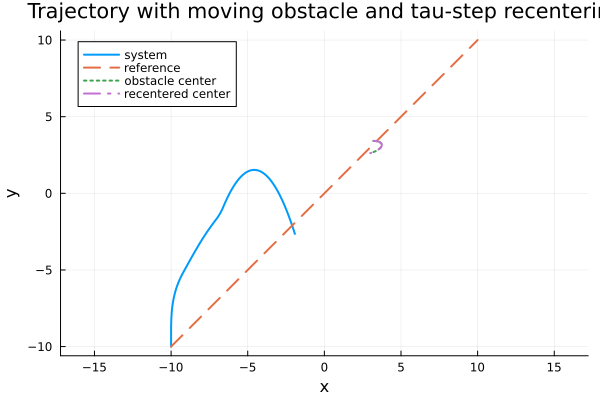

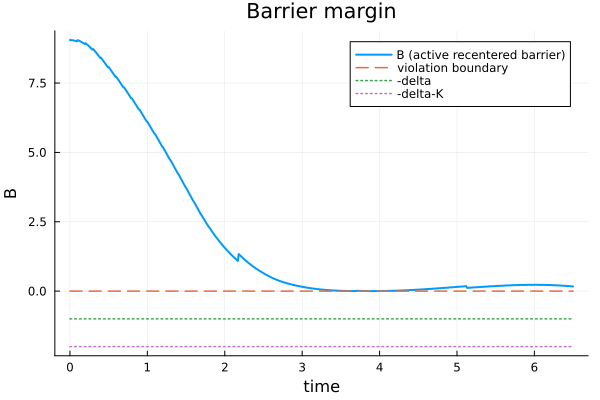

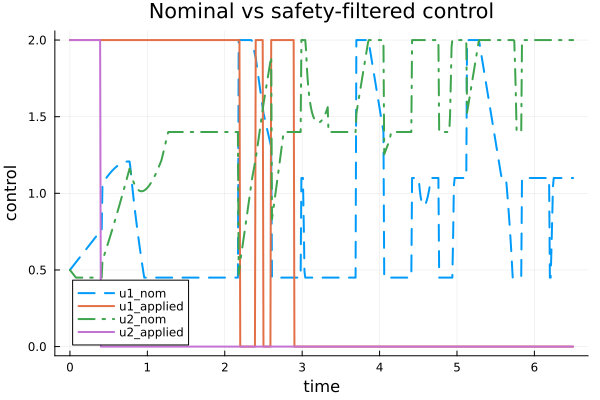

Override steps (total): 650
Emergency override steps (red markers): 0
Min distance to obstacle center: 6.6744 (radius = 0.1)
Collision detected (distance <= radius): false
Saved GIF: figures/repulsive_hybrid_planar_multirotor.gif


In [15]:
include("Repulsive_hybrid_planar_multirotor7D_recenter_fix.jl")

all_B = [B_1, B_2, B_3, B_4]
# K_sim = maximum([K_1, K_2, K_3, K_4])
K_sim = K

res = RepulsiveHybridPlanarMultirotorRecenterFix.run_repulsive_hybrid_planar_multirotor_demo(
    Bs = all_B,
    U = U,
    K = K_sim,
    delta = 1.0,
    alpha = 0.1,
    tau = 0.1,
    dt = 0.01,
    T = 6.5,
    x0 = [-10.0, -10.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    ref_start = (-10.0, -10.0),
    ref_end = (10.0, 10.0),
    ref_T = 6.5,
    v_obs = (0.55, 0.42),
    x0_obs = (3.2, 3.0),
    gif_file = "figures/repulsive_hybrid_planar_multirotor.gif",
)

display(res.p_traj)
display(res.p_B)
display(res.p_u)
println("Override steps (total): ", res.n_override)
println("Emergency override steps (red markers): ", res.n_emergency_override)
println("Min distance to obstacle center: ", round(res.min_dist_to_obs, digits=4), " (radius = 0.1)")
println("Collision detected (distance <= radius): ", res.collision)
println("Saved GIF: ", res.gif_path)